# A decision tree, built from scratch

Entropy, information gain, threshold search and recursive tree construction, written directly in NumPy. No `sklearn.tree` anywhere below the imports.

The tree is then used to predict red wine quality from eleven physicochemical measurements.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

## The data

UCI red wine quality: 1,599 wines, eleven continuous features, and a quality score from 0 to 10 assigned by tasters.

The file is semicolon-separated rather than comma-separated.

In [2]:
data = pd.read_csv("winequality-red.csv", sep=";")
print(data.shape)
data.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Quality is ordinal, but the ratings cluster heavily around 5 and 6 and the extremes are almost empty. Splitting at 6 turns this into a binary problem with a nearly even class balance, which is what the tree below is built to handle.

This does throw information away — a 3 and a 5 become the same label — and that limitation is worth keeping in mind when reading the accuracy figures.

In [3]:
print(data["quality"].value_counts().sort_index())

parameters = data.drop("quality", axis=1)
result = (data["quality"] >= 6).astype(int)

print("\nGood (>= 6):", result.mean().round(3))

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Good (>= 6): 0.535


## Splitting the data three ways

The stopping depth is a hyperparameter, so it has to be chosen on data that is not the test set. Choosing it by test accuracy would mean the reported score is tuned rather than held out, and no longer estimates performance on unseen wines.

So: 20% is set aside as a test set and left alone. The remaining 80% is split again, 75/25, into training and validation. The depth is chosen on validation. The test set is touched exactly once, at the end.

In [4]:
Par_full, Par_test, Res_full, Res_test = train_test_split(
    parameters, result, test_size=0.2, random_state=26)

Par_train, Par_val, Res_train, Res_val = train_test_split(
    Par_full, Res_full, test_size=0.25, random_state=26)

features_train, labels_train = Par_train.values, Res_train.values
features_val,   labels_val   = Par_val.values,   Res_val.values
features_test,  labels_test  = Par_test.values,  Res_test.values

print(f"train      {features_train.shape}   positive rate {labels_train.mean():.3f}")
print(f"validation {features_val.shape}   positive rate {labels_val.mean():.3f}")
print(f"test       {features_test.shape}   positive rate {labels_test.mean():.3f}")

train      (959, 11)   positive rate 0.550
validation (320, 11)   positive rate 0.522
test       (320, 11)   positive rate 0.503


## Entropy

Entropy measures how mixed a set of labels is. A node containing only good wines, or only bad ones, has entropy 0. A 50/50 node has entropy 1, the maximum for two classes.

$$H(y) = -p_1\log_2 p_1 - p_0\log_2 p_0$$

The guards on `p > 0` matter: $\log_2 0$ is undefined, and by convention $0\log_2 0 = 0$.

In [5]:
def calc_entropy(array_res):
    n = len(array_res)
    if n == 0:
        return 0.0

    p1 = np.sum(array_res == 1) / n
    p0 = np.sum(array_res == 0) / n

    ent = 0.0
    if p1 > 0:
        ent -= p1 * np.log2(p1)
    if p0 > 0:
        ent -= p0 * np.log2(p0)
    return ent


print("all good      ", calc_entropy(np.array([1, 1, 1, 1])))
print("even split    ", calc_entropy(np.array([1, 1, 0, 0])))
print("three to one  ", round(calc_entropy(np.array([1, 1, 1, 0])), 4))

all good       0.0
even split     1.0
three to one   0.8113


## Information gain

A split is worth making if it reduces entropy. Information gain is the parent's entropy minus the entropy of its two children, weighted by how many samples land in each.

The weighting is what stops the search from favouring splits that peel off a single pure sample: a child holding two rows contributes almost nothing to the average, however pure it is.

In [6]:
def calc_information_gain(array_res, left_idx, right_idx):
    n = len(array_res)

    entropy_parent = calc_entropy(array_res)
    entropy_children = (
        len(left_idx)  * calc_entropy(array_res[left_idx]) +
        len(right_idx) * calc_entropy(array_res[right_idx])
    ) / n

    return entropy_parent - entropy_children


y = np.array([1, 1, 1, 0, 0, 0])
print("perfect split", calc_information_gain(y, np.array([0,1,2]), np.array([3,4,5])))
print("useless split", calc_information_gain(y, np.array([0,3,4]), np.array([1,2,5])))

perfect split 1.0
useless split 0.08170416594551044


## Finding the best split

All eleven features are continuous, so a split is a feature plus a threshold. The search is exhaustive: for every feature, try every value that actually occurs as a threshold, and keep whichever pair gives the most information gain.

Splits that send every sample to one side are skipped — they gain nothing and would recurse forever.

In [7]:
def best_split(inputs, output):
    n_samples, n_features = inputs.shape

    best_info_gain = -1
    best_feature = None
    best_threshold = None

    for feature in range(n_features):
        for threshold in np.unique(inputs[:, feature]):
            left_idx  = np.where(inputs[:, feature] <= threshold)[0]
            right_idx = np.where(inputs[:, feature] >  threshold)[0]

            if len(left_idx) == 0 or len(right_idx) == 0:
                continue

            ig = calc_information_gain(output, left_idx, right_idx)
            if ig > best_info_gain:
                best_info_gain = ig
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_info_gain


f, t, g = best_split(features_train, labels_train)
print(f"Best first split: {parameters.columns[f]} <= {t}")
print(f"Information gain: {g:.4f}")

Best first split: alcohol <= 11.1
Information gain: 0.1175


## Building the tree

The tree is a nested dictionary. An internal node holds a feature index, a threshold, and two subtrees. A leaf holds a single predicted class.

Recursion stops on any of three conditions:

1. the node is pure, so there is nothing left to separate;
2. the maximum depth is reached, which is the only complexity control here;
3. no split produces positive information gain, meaning the features cannot separate what remains.

In cases 2 and 3 the leaf predicts whichever class is in the majority.

In [8]:
def train_decision_tree(inputs, output, depth=0, stopping_depth=None):
    # 1. pure node
    if len(np.unique(output)) == 1:
        return {"leaf": int(output[0])}

    # 2. depth limit reached
    if stopping_depth is not None and depth >= stopping_depth:
        return {"leaf": 1 if np.sum(output == 1) >= np.sum(output == 0) else 0}

    feature, threshold, ig = best_split(inputs, output)

    # 3. no split helps
    if feature is None or ig <= 0:
        return {"leaf": 1 if np.sum(output == 1) >= np.sum(output == 0) else 0}

    left_idx  = np.where(inputs[:, feature] <= threshold)[0]
    right_idx = np.where(inputs[:, feature] >  threshold)[0]

    return {
        "feature":   feature,
        "threshold": threshold,
        "left":      train_decision_tree(inputs[left_idx],  output[left_idx],  depth + 1, stopping_depth),
        "right":     train_decision_tree(inputs[right_idx], output[right_idx], depth + 1, stopping_depth),
    }

## Prediction

Traversal is a walk from the root: at each internal node, compare the sample's value for that feature against the threshold and go left or right. When a leaf is reached, return its class.

In [9]:
def predict_sample(node, sample):
    while "leaf" not in node:
        if sample[node["feature"]] <= node["threshold"]:
            node = node["left"]
        else:
            node = node["right"]
    return node["leaf"]


def predict_tree(tree, X):
    return np.array([predict_sample(tree, sample) for sample in X])

## Choosing the stopping depth

Sweeping depth 1 to 7 and scoring each on the **validation** set. The test set plays no part in this.

Shallow trees underfit: at depth 1 the model is a single split, a decision stump. Deep trees begin carving out regions that fit the training data's noise rather than any real pattern, and validation accuracy falls back.

In [10]:
val_scores = {}

for depth in range(1, 8):
    tree = train_decision_tree(features_train, labels_train, stopping_depth=depth)
    acc = np.mean(predict_tree(tree, features_val) == labels_val)
    val_scores[depth] = acc
    print(f"Depth {depth}: validation accuracy = {acc:.4f}")

best_depth = max(val_scores, key=val_scores.get)
print(f"\nSelected stopping depth: {best_depth}")

Depth 1: validation accuracy = 0.6344


Depth 2: validation accuracy = 0.6906


Depth 3: validation accuracy = 0.7438


Depth 4: validation accuracy = 0.7594


Depth 5: validation accuracy = 0.7438


Depth 6: validation accuracy = 0.7281


Depth 7: validation accuracy = 0.7438

Selected stopping depth: 4


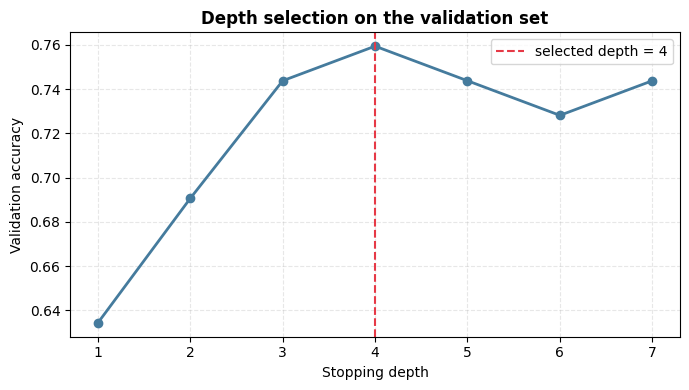

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(val_scores), list(val_scores.values()), marker="o", color="#457b9d", linewidth=2)
ax.axvline(best_depth, color="#e63946", linestyle="--", linewidth=1.5,
           label=f"selected depth = {best_depth}")
ax.set_xlabel("Stopping depth")
ax.set_ylabel("Validation accuracy")
ax.set_title("Depth selection on the validation set", fontweight="bold")
ax.grid(alpha=0.3, linestyle="--")
ax.legend()
plt.tight_layout()
plt.show()

## Final evaluation

The depth is now fixed. The tree is retrained on training plus validation combined — there is no reason to discard the validation rows once they have served their purpose — and scored on the test set once.

Because selection never involved the test set, this figure is an unbiased estimate of accuracy on unseen wines.

In [12]:
final_tree = train_decision_tree(
    np.vstack([features_train, features_val]),
    np.concatenate([labels_train, labels_val]),
    stopping_depth=best_depth,
)

predictions = predict_tree(final_tree, features_test)
test_acc = np.mean(predictions == labels_test)

majority = 1 if np.concatenate([labels_train, labels_val]).mean() >= 0.5 else 0
baseline = np.mean(labels_test == majority)

print(f"Test accuracy      {test_acc:.4f}   ({int(test_acc * len(labels_test))} of {len(labels_test)})")
print(f"Macro F1           {f1_score(labels_test, predictions, average='macro'):.4f}")
print(f"Majority baseline  {baseline:.4f}")

Test accuracy      0.7156   (229 of 320)
Macro F1           0.7144
Majority baseline  0.5031


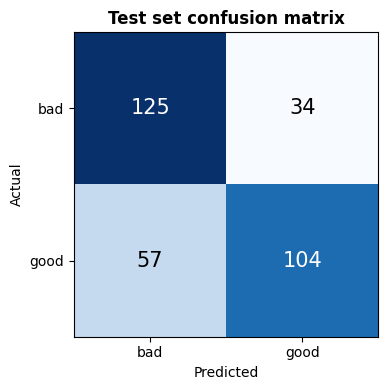

Precision (good)  0.754
Recall    (good)  0.646


In [13]:
cm = confusion_matrix(labels_test, predictions)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=15,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xticks([0, 1], ["bad", "good"])
ax.set_yticks([0, 1], ["bad", "good"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Test set confusion matrix", fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Precision (good)  {tp / (tp + fp):.3f}")
print(f"Recall    (good)  {tp / (tp + fn):.3f}")

## Is the implementation actually correct?

A from-scratch algorithm is only worth anything if it does what it claims. Running scikit-learn's tree with the same criterion and the same depth gives a useful check: the two should land in roughly the same place and split on the same variable first.

They do. Small differences in accuracy are expected — the two implementations break ties between equally good splits differently, and scikit-learn evaluates thresholds at midpoints between observed values rather than at the values themselves.

In [14]:
from sklearn.tree import DecisionTreeClassifier

reference = DecisionTreeClassifier(criterion="entropy", max_depth=best_depth,
                                   random_state=26).fit(Par_full, Res_full)

print(f"from scratch   {test_acc:.4f}   root: {parameters.columns[final_tree['feature']]} <= {final_tree['threshold']}")
print(f"scikit-learn   {reference.score(Par_test, Res_test):.4f}   "
      f"root: {parameters.columns[reference.tree_.feature[0]]} <= {reference.tree_.threshold[0]:.3f}")

from scratch   0.7156   root: alcohol <= 9.95
scikit-learn   0.7063   root: alcohol <= 9.975


## What the tree learned

Printing the structure shows which measurements the model relies on and where it cuts them.

In [15]:
def print_tree(node, columns, indent=""):
    if "leaf" in node:
        print(f"{indent}-> {'good' if node['leaf'] == 1 else 'bad'}")
        return
    print(f"{indent}{columns[node['feature']]} <= {node['threshold']}")
    print_tree(node["left"],  columns, indent + "    ")
    print_tree(node["right"], columns, indent + "    ")


print_tree(final_tree, parameters.columns, "")

alcohol <= 9.95


    total sulfur dioxide <= 98.0
        sulphates <= 0.57
            total sulfur dioxide <= 88.0
                -> bad
                -> good
            fixed acidity <= 10.7
                -> bad
                -> good
        pH <= 2.93
            -> good
            chlorides <= 0.066
                -> bad
                -> bad
    alcohol <= 11.5
        sulphates <= 0.59
            volatile acidity <= 0.31
                -> good
                -> bad
            total sulfur dioxide <= 85.0
                -> good
                -> bad
        volatile acidity <= 0.49
            density <= 0.9956
                -> good
                -> good
            sulphates <= 0.63
                -> good
                -> good


## Conclusions

The tree reaches **71.6% accuracy** on held-out wines, against a **50.3%** majority-class baseline — a 21 point improvement from eleven chemical measurements and no domain knowledge.

The first split is on **alcohol**, at roughly 10% by volume. Wines below that threshold are markedly more likely to be rated poorly. That single split alone recovers most of what a depth-one stump can achieve, and it survives at the root under scikit-learn's implementation too, so it is a property of the data rather than an artefact of this code.

Validation accuracy peaks at depth 4 and declines afterwards. That decline is overfitting made visible: the extra depth buys splits that describe the training set's noise and do not generalise.

### Limitations

- **Threshold search is exhaustive**, costing O(features x unique values) per node with a full entropy recomputation each time. Fine on 1,599 rows, hopeless at scale. A production implementation sorts each feature once and updates class counts incrementally as the threshold sweeps.
- **Depth is the only complexity control.** No minimum samples per leaf, no cost-complexity pruning, no minimum gain threshold.
- **Binary classification only.** Multi-class would need entropy generalised over k classes; regression would need variance reduction in place of information gain.
- **Binarising quality at 6 discards ordinal information.** A wine rated 3 and one rated 5 are treated as identical, and the cut point is arbitrary.
- **A single train/validation/test split.** Cross-validation would give a more stable depth choice and an error bar on the accuracy figure, which on 320 test wines is worth about plus or minus 2.5 points.